In [1]:
# ==== Bloco 1: Importar bibliotecas ====

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from statsmodels.tsa.stattools import pacf
import joblib


Tamanho da série: 1500
Regimes únicos: [0. 1. 2.]


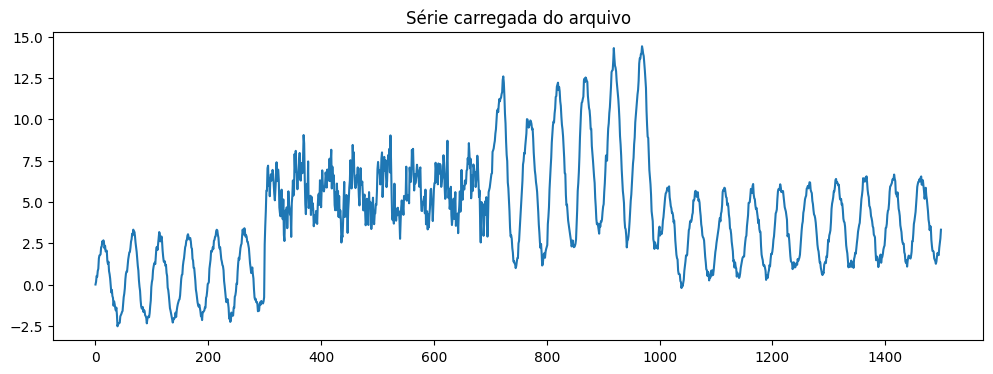

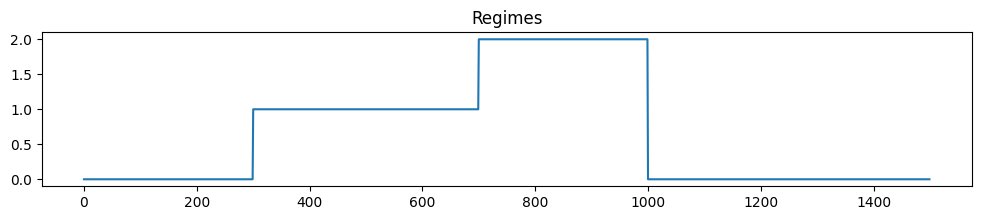

In [2]:
# ==== Bloco 2: Carregar série temporal + regimes ====

data = np.loadtxt("series_realista_completo.txt", skiprows=1)

y = data[:, 0]       # série
regime = data[:, 1]  # regimes (0, 1, 2...)

print("Tamanho da série:", len(y))
print("Regimes únicos:", np.unique(regime))

plt.figure(figsize=(12,4))
plt.plot(y)
plt.title("Série carregada do arquivo")
plt.show()

plt.figure(figsize=(12,2))
plt.plot(regime)
plt.title("Regimes")
plt.show()


In [3]:
# ==== Bloco 3: Funções auxiliares ====

def create_sequences(df_values, past_steps=48, horizon=1):
    n = len(df_values)
    X, y = [], []
    for i in range(past_steps, n - horizon + 1):
        X.append(df_values[i - past_steps:i, :])
        y.append(df_values[i + horizon - 1, 0])
    return np.array(X), np.array(y)

def train_val_test_split_time(X, y, train_frac=0.7, val_frac=0.15):
    n = X.shape[0]
    train_end = int(n * train_frac)
    val_end = int(n * (train_frac + val_frac))
    return (
        X[:train_end], y[:train_end],
        X[train_end:val_end], y[train_end:val_end],
        X[val_end:], y[val_end:]
    )

def evaluate_preds(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    return {'MAE': mae, 'RMSE': rmse, 'MAPE(%)': mape}

def build_lstm_baseline(seq_len, n_feats, units=64, dropout=0.2):
    inp = layers.Input(shape=(seq_len, n_feats))
    x = layers.LSTM(units)(inp)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(1)(x)
    model = models.Model(inp, out)
    model.compile(optimizer=optimizers.Adam(1e-3), loss='mse')
    return model

def escolher_lag_pacf(y_norm, max_lag=40, alpha=0.05):
    pacf_vals, conf = pacf(y_norm, nlags=max_lag, alpha=alpha)
    sig = []
    for lag in range(1, len(pacf_vals)):
        low, high = conf[lag]
        if pacf_vals[lag] < low or pacf_vals[lag] > high:
            sig.append(lag)
    return max(sig) if sig else 1

def persistence_forecast(X):
    return X[:, -1, 0]


In [4]:
# ==== Bloco 4: Mistura de Especialistas (MoE) ====

def build_mixture_of_experts(seq_len, n_feats,
                             n_experts=3, expert_units=32,
                             gating_units=32, dropout=0.2):

    inp = layers.Input(shape=(seq_len, n_feats), name='input_seq')

    expert_outputs = []
    for k in range(n_experts):
        x = layers.LSTM(expert_units, return_sequences=False)(inp)
        x = layers.Dropout(dropout)(x)
        out_k = layers.Dense(1)(x)
        expert_outputs.append(out_k)

    experts_concat = layers.Concatenate(axis=1)(expert_outputs)

    pooled = layers.GlobalAveragePooling1D()(inp)
    g = layers.Dense(gating_units, activation='relu')(pooled)
    g = layers.Dropout(0.1)(g)
    g_logits = layers.Dense(n_experts)(g)
    g_soft = layers.Activation('softmax')(g_logits)

    weighted = layers.Multiply()([experts_concat, g_soft])
    final_out = layers.Lambda(lambda x: tf.reduce_sum(x, axis=1, keepdims=True))(weighted)

    model = models.Model(inp, final_out)
    model.compile(optimizer=optimizers.Adam(1e-3), loss='mse')
    return model


In [5]:
# ==== Bloco 5: Normalização e escolha automática do lag ====

scaler = StandardScaler()
y_norm = scaler.fit_transform(y.reshape(-1, 1)).flatten()

lag_sugerido = escolher_lag_pacf(y_norm, max_lag=40)
print("Lag sugerido pela PACF:", lag_sugerido)

past_steps = lag_sugerido
horizon = 1

arr = y_norm.reshape(-1, 1)
n_feats = arr.shape[1]


Lag sugerido pela PACF: 1


In [6]:
# ==== Bloco 6: Criar janelas + split ====

X_all, y_all = create_sequences(arr, past_steps=past_steps, horizon=horizon)

X_train, y_train, X_val, y_val, X_test, y_test = train_val_test_split_time(
    X_all, y_all, 0.7, 0.15
)

print("Formato X_train:", X_train.shape)
print("Formato X_val:", X_val.shape)
print("Formato X_test:", X_test.shape)


Formato X_train: (1049, 1, 1)
Formato X_val: (225, 1, 1)
Formato X_test: (225, 1, 1)


In [7]:
# ==== Bloco 7: LSTM Baseline ====

lstm = build_lstm_baseline(past_steps, n_feats, units=64, dropout=0.2)
lstm.summary()

es = callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

lstm.fit(X_train, y_train,
         validation_data=(X_val, y_val),
         epochs=80, batch_size=64, callbacks=[es], verbose=1)

y_pred_lstm = lstm.predict(X_test).reshape(-1)
print("LSTM metrics:", evaluate_preds(y_test, y_pred_lstm))


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 1.3738 - val_loss: 0.4115
Epoch 2/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 1.2235 - val_loss: 0.3760
Epoch 3/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.1084 - val_loss: 0.3335
Epoch 4/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.8955 - val_loss: 0.2944
Epoch 5/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.7183 - val_loss: 0.2523
Epoch 6/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6096 - val_loss: 0.2035
Epoch 7/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4772 - val_loss: 0.1526
Epoch 8/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3392 - val_loss: 0.1052
Epoch 9/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2420 - val_loss: 0.0652
Epoch 10/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1665 - val_loss: 0.0367
Epoch 11/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1059 - val_loss: 0.0217
Epoch 12/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0824 - va

In [8]:
# ==== Bloco 8: Mistura de Especialistas ====

moe = build_mixture_of_experts(
    past_steps, n_feats,
    n_experts=3,
    expert_units=48,
    gating_units=32
)
moe.summary()

es2 = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

moe.fit(X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=120, batch_size=64, callbacks=[es2], verbose=1)

y_pred_moe = moe.predict(X_test).reshape(-1)
print("MOE metrics:", evaluate_preds(y_test, y_pred_moe))


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_seq           │ (None, 1, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1)         │          0 │ input_seq[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 48)        │      9,600 │ input_seq[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 48)        │      9,600 │ input_seq[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 48)        │      9,600 │ input_seq[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │         64 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 48)        │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 48)        │          0 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 48)        │          0 │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 32)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         49 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         49 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         49 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 3)         │         99 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 3)         │          0 │ dense_1[0][0],    │
│ (Concatenate)       │                   │            │ dense_2[0][0],    │
│                     │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 3)         │          0 │ dense_5[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 3)         │          0 │ concatenate[0][0… │
│                     │                   │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 1)         │          0 │ multiply[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 29,110 (113.71 KB)

 Trainable params: 29,110 (113.71 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/120
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 153ms/step - loss: 1.2085 - val_loss: 0.3503
Epoch 2/120
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1.1087 - val_loss: 0.3110
Epoch 3/120
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.9760 - val_loss: 0.2656
Epoch 4/120
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.7828 - val_loss: 0.2100
Epoch 5/120
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.5677 - val_loss: 0.1438
Epoch 6/120
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3735 - val_loss: 0.0782
Epoch 7/120
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1897 - val_loss: 0.0289
Epoch 8/120
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0874 - val_loss: 0.0129
Epoch 9/120
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0613 - val_loss: 0.0127
Epoch 10/120
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0604 - val_loss: 0.0127
Epoch 11/120
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0600 - val_loss: 0.0117
Epoch 12/120
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/ste

In [9]:
# ==== Bloco 9: Baseline de persistência ====

y_pred_base = persistence_forecast(X_test)
print("Baseline metrics:", evaluate_preds(y_test, y_pred_base))


Baseline metrics: {'MAE': 0.08110754187008058, 'RMSE': np.float64(0.09841759276677245), 'MAPE(%)': np.float64(297.76948209241243)}


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Gating mean weights per expert: [0.4065444  0.41093853 0.18251726]


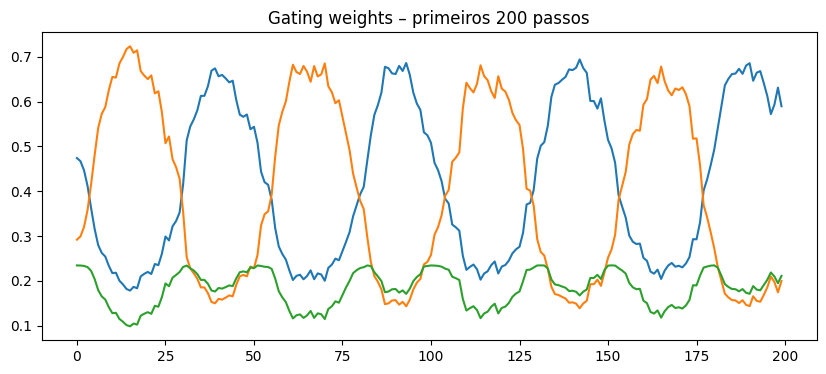

In [10]:
# ==== Bloco 10: Análise da gating ====

get_gating = models.Model(inputs=moe.input,
                          outputs=moe.get_layer('activation').output)

g_vals = get_gating.predict(X_test)

print("Gating mean weights per expert:", g_vals.mean(axis=0))

plt.figure(figsize=(10,4))
plt.plot(g_vals[:200])
plt.title("Gating weights – primeiros 200 passos")
plt.show()


In [11]:
# ==== Bloco 11: Salvar modelos ====

moe.save("moe_lstm_model.h5")
lstm.save("lstm_baseline.h5")
joblib.dump(scaler, "scaler.save")

print("Modelos e scaler foram salvos com sucesso.")


Modelos e scaler foram salvos com sucesso.
